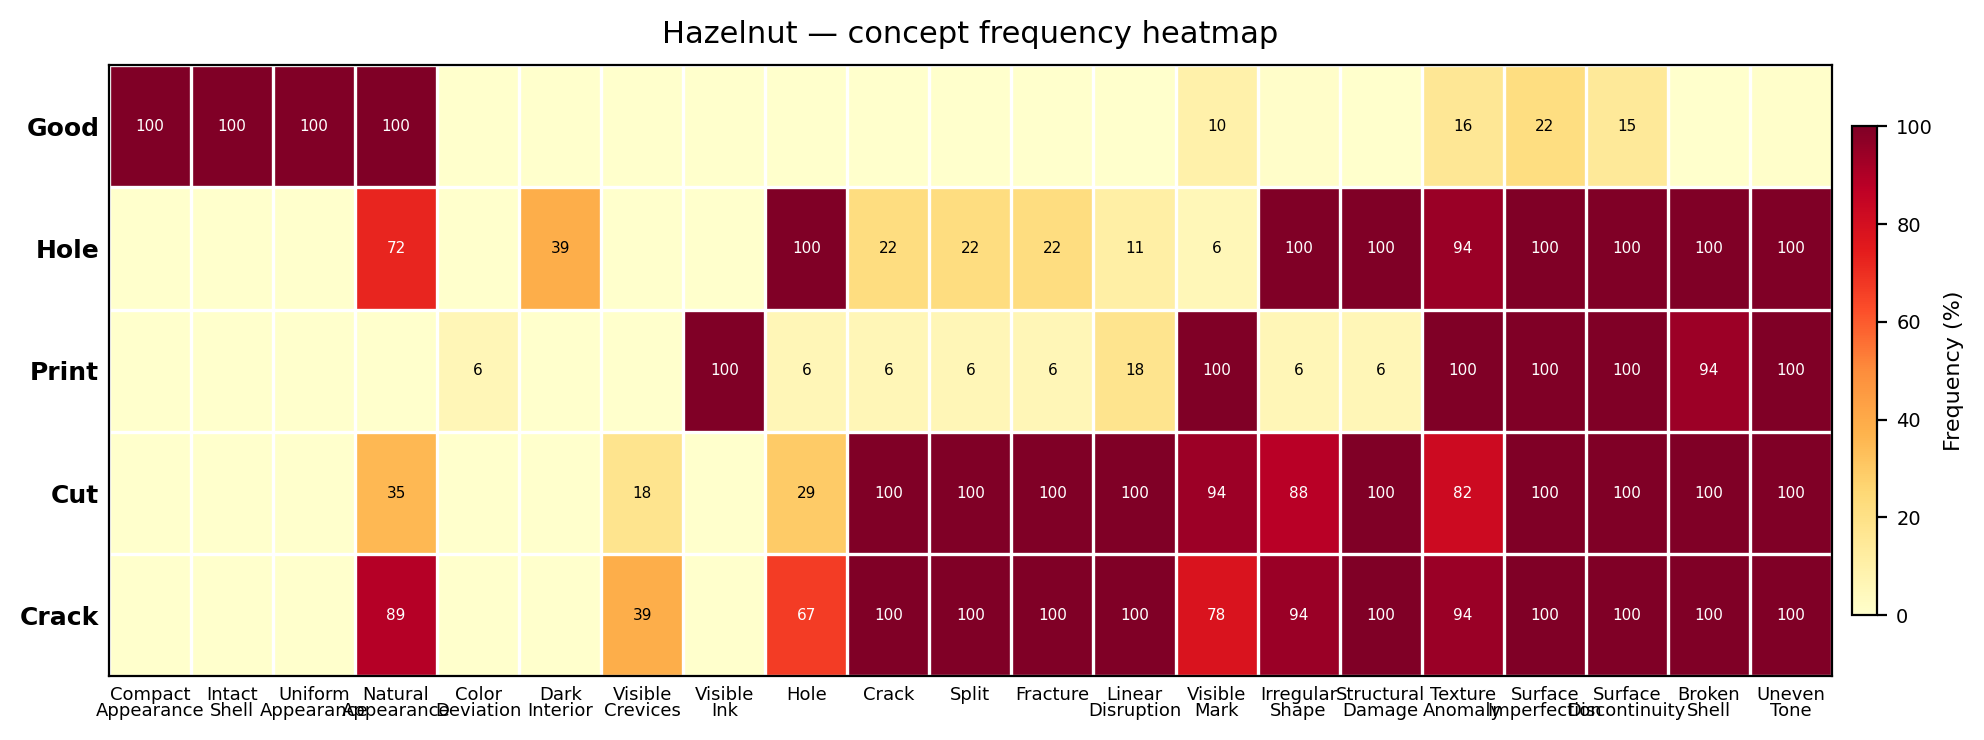

Saved → alt_1_heatmap.png


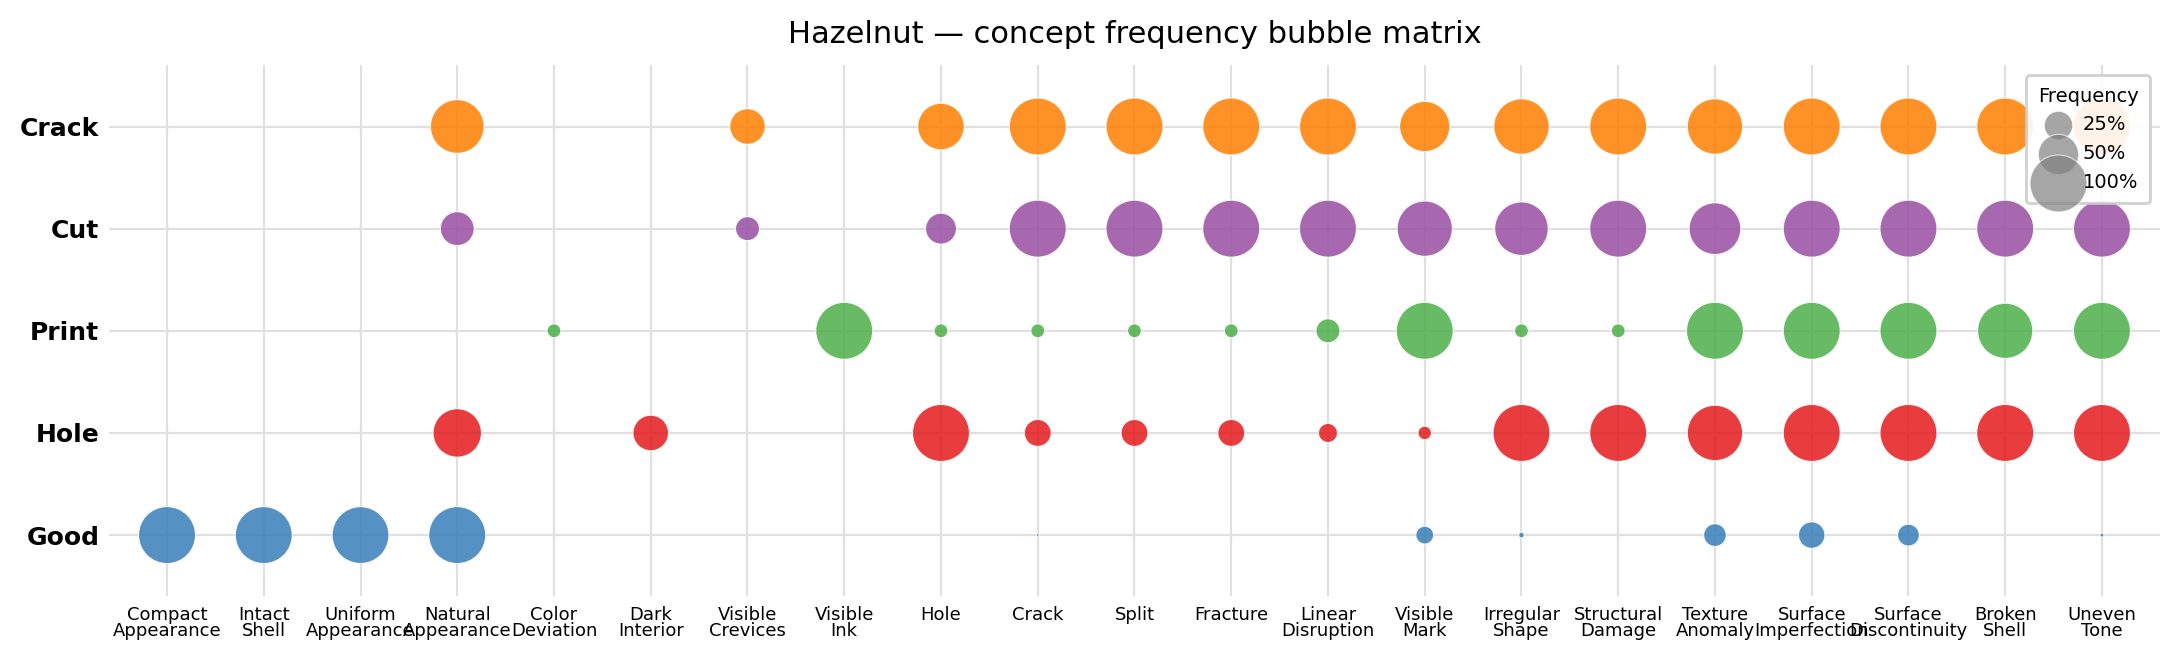

Saved → alt_2_bubble_matrix.png


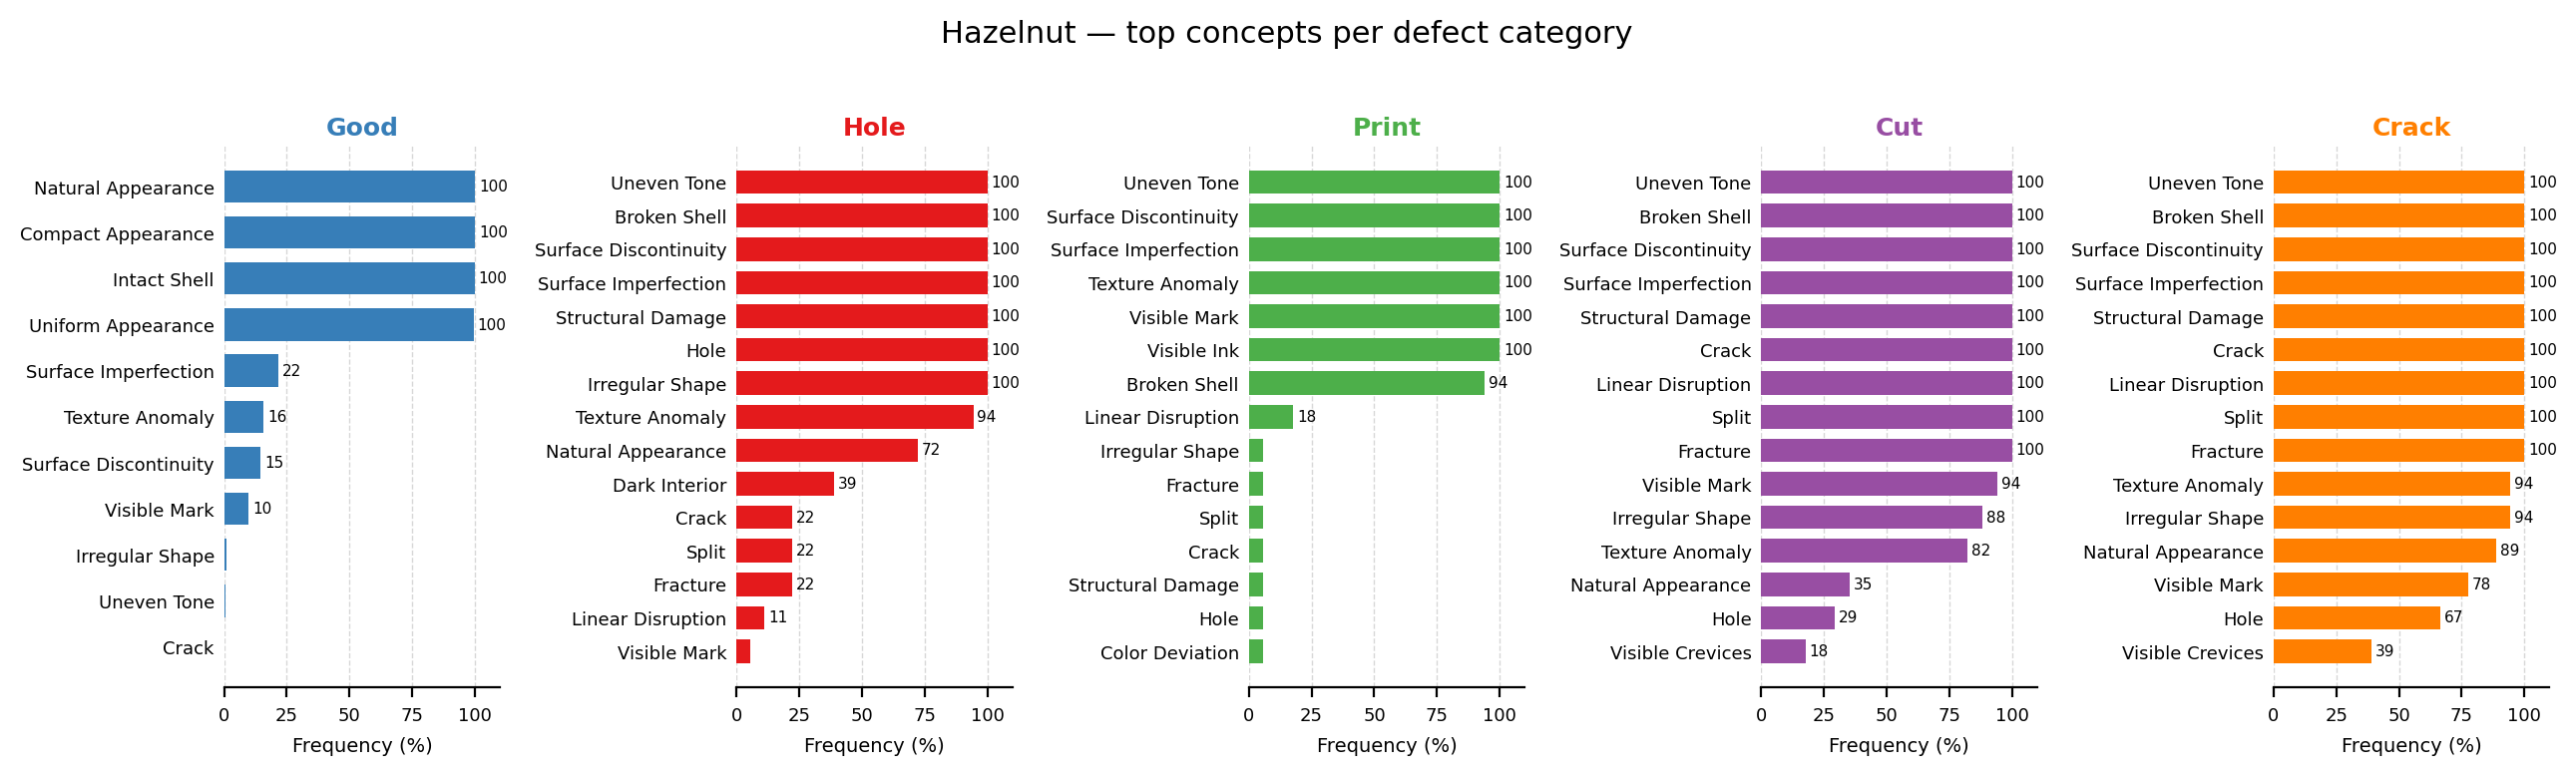

Saved → alt_3_sorted_bars.png


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import FancyArrowPatch
from pathlib import Path

"""
Alternative visualizations for the hazelnut defect concept frequency data.
Run any of the three functions independently — all share the same data-loading block.
"""


# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv("plot_data_mvtec_hazelnut.csv")
concepts = df["concept"].tolist()
categories = [c for c in df.columns if c != "concept"]
data = df[categories].values          # shape: (n_concepts, n_categories)
category_labels = [c.replace("_", " ").title() for c in categories]

cmap_set1 = plt.get_cmap("Set1")
# Match the original color ordering (good=blue, hole=red, print=green, cut=purple, crack=orange)
ordering = {0: 1, 1: 0, 2: 2, 3: 3, 4: 4}
colors = [cmap_set1(ordering[i] % 8) for i in range(len(categories))]


# ══════════════════════════════════════════════════════════════════════════════
# 1. HEATMAP  ─ most compact, best for sparse data
# ══════════════════════════════════════════════════════════════════════════════
def plot_heatmap():
    fig, ax = plt.subplots(figsize=(11, 3.8), dpi=200)

    mat = data.T   # (n_categories, n_concepts)

    im = ax.imshow(mat, aspect="auto", cmap="YlOrRd", vmin=0, vmax=100,
                   interpolation="nearest")

    # Annotate cells with value when > 0
    for r in range(mat.shape[0]):
        for c in range(mat.shape[1]):
            v = mat[r, c]
            if v > 5:
                ax.text(c, r, f"{v:.0f}", ha="center", va="center",
                        fontsize=5.5,
                        color="white" if v > 60 else "black")

    ax.set_xticks(range(len(concepts)))
    ax.set_xticklabels(
        [c.replace(" ", "\n") for c in concepts],
        fontsize=6.5, rotation=0, linespacing=0.85
    )
    ax.set_yticks(range(len(categories)))
    ax.set_yticklabels(category_labels, fontweight="bold", fontsize=9)
    ax.tick_params(length=0)

    # Light grid
    ax.set_xticks(np.arange(-0.5, len(concepts)), minor=True)
    ax.set_yticks(np.arange(-0.5, len(categories)), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.2)
    ax.tick_params(which="minor", length=0)

    cb = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.01)
    cb.set_label("Frequency (%)", fontsize=8)
    cb.ax.tick_params(labelsize=7)

    ax.set_title("Hazelnut — concept frequency heatmap", fontsize=11, pad=8)
    fig.tight_layout()
    plt.savefig("alt_1_heatmap.png", dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()
    print("Saved → alt_1_heatmap.png")


# ══════════════════════════════════════════════════════════════════════════════
# 2. BUBBLE MATRIX  ─ same grid, circles sized by frequency; easier to read
#                     than a heatmap when values are very sparse
# ══════════════════════════════════════════════════════════════════════════════
def plot_bubble_matrix():
    n_concepts = len(concepts)
    n_cats = len(categories)

    fig, ax = plt.subplots(figsize=(11, 3.4), dpi=200)

    xs, ys, sizes, bubble_colors = [], [], [], []
    for ci, cat_vals in enumerate(data.T):       # iterate categories (rows)
        for xi, v in enumerate(cat_vals):        # iterate concepts (cols)
            if v > 0:
                xs.append(xi)
                ys.append(ci)
                sizes.append((v / 100) * 420)    # max bubble ≈ 420 pt²
                bubble_colors.append(colors[ci])

    ax.scatter(xs, ys, s=sizes, c=bubble_colors, alpha=0.85,
               linewidths=0.4, edgecolors="white", zorder=3)

    # Reference grid
    ax.set_xlim(-0.6, n_concepts - 0.4)
    ax.set_ylim(-0.6, n_cats - 0.4)
    ax.set_xticks(range(n_concepts))
    ax.set_yticks(range(n_cats))
    ax.set_xticklabels(
        [c.replace(" ", "\n") for c in concepts],
        fontsize=6.5, linespacing=0.85
    )
    ax.set_yticklabels(category_labels, fontweight="bold", fontsize=9)
    ax.tick_params(length=0)
    ax.grid(color="#e0e0e0", linewidth=0.8, zorder=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Legend for bubble size
    for pct in (25, 50, 100):
        ax.scatter([], [], s=(pct / 100) * 420, c="grey", alpha=0.7,
                   label=f"{pct}%", edgecolors="white", linewidths=0.4)
    ax.legend(title="Frequency", title_fontsize=7, fontsize=7,
              loc="upper right", framealpha=0.9,
              handletextpad=0.3, borderpad=0.6)

    ax.set_title("Hazelnut — concept frequency bubble matrix", fontsize=11, pad=8)
    fig.tight_layout()
    plt.savefig("alt_2_bubble_matrix.png", dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()
    print("Saved → alt_2_bubble_matrix.png")


# ══════════════════════════════════════════════════════════════════════════════
# 3. STACKED HORIZONTAL BAR (% of concepts active per defect type)
#    + small multiples sorted bar — two panels side by side
#    Useful to compare which defect types share concepts
# ══════════════════════════════════════════════════════════════════════════════
def plot_sorted_bars():
    """
    One horizontal subplot per defect category.
    Concepts sorted by frequency descending → easy to spot the key descriptors.
    Very clean, compact, and print-friendly.
    """
    n_cats = len(categories)
    fig, axes = plt.subplots(1, n_cats, figsize=(13, 3.8), dpi=200,
                             sharey=False)
    fig.subplots_adjust(wspace=0.35)

    for i, (ax, cat) in enumerate(zip(axes, categories)):
        vals = data[:, i]
        order = np.argsort(vals)[::-1]
        sorted_vals = vals[order]
        sorted_labels = [concepts[j] for j in order]

        # Keep only non-zero
        nonzero = sorted_vals > 0
        sv = sorted_vals[nonzero]
        sl = [l for l, nz in zip(sorted_labels, nonzero) if nz]

        y = np.arange(len(sv))
        bars = ax.barh(y, sv, color=colors[i], edgecolor="none", height=0.7)

        ax.set_yticks(y)
        ax.set_yticklabels(sl, fontsize=6.5)
        ax.invert_yaxis()
        ax.set_xlim(0, 110)
        ax.set_xlabel("Frequency (%)", fontsize=7)
        ax.set_title(category_labels[i], fontweight="bold",
                     fontsize=9, color=colors[i], pad=4)
        ax.tick_params(axis="x", labelsize=6.5)
        ax.tick_params(axis="y", length=0)
        ax.xaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
        ax.set_axisbelow(True)
        for spine in ["top", "right", "left"]:
            ax.spines[spine].set_visible(False)

        # Value labels on bars
        for bar, v in zip(bars, sv):
            if v > 8:
                ax.text(v + 1.5, bar.get_y() + bar.get_height() / 2,
                        f"{v:.0f}", va="center", fontsize=5.5)

    fig.suptitle("Hazelnut — top concepts per defect category", fontsize=11, y=1.01)
    fig.tight_layout()
    plt.savefig("alt_3_sorted_bars.png", dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()
    print("Saved → alt_3_sorted_bars.png")


# ── Run all three ─────────────────────────────────────────────────────────────
if __name__ == "__main__":
    plot_heatmap()
    plot_bubble_matrix()
    plot_sorted_bars()